<a href="https://colab.research.google.com/github/GroupQ-Assignment-DataScience/GroupQ_Assignment_RMD/blob/main/GroupQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
from matplotlib import pyplot as plt
from sklearn import preprocessing

In [17]:
import pandas as pd
df = pd.read_csv('/content/dataset_C_training.csv')

In [18]:
df.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [19]:
# Install H20AutoML (only need to do this once)
!pip install h2o

# Import packages
import h2o
from h2o.automl import H2OAutoML

# Start the H2O cluster (locally)
h2o.init()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 5.2 MB/s eta 0:00:00
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp56oxnvml
  JVM stdout: /tmp/tmp56oxnvml/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp56oxnvml/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,05 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,"14 days, 1 hour and 25 minutes"
H2O_cluster_name:,H2O_from_python_unknownUser_zhebvo
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.147 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [20]:
# Define the target variable (i.e. "response") and features (i.e. "predictors") for H20AutoML
response = 'covid_vaccine'
predictors = list(df.drop('covid_vaccine', axis=1).columns)

# Convert from a pandas dataframe to an h20 frame
hf = h2o.H2OFrame(df)

# Convert target column to categorical, as this is a binary classification problem
hf['covid_vaccine'] = hf['covid_vaccine'].asfactor()

# Split the data into training and testing sets using the H20 split_frame() method
train, test = hf.split_frame(seed=1, ratios=[0.75])

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [21]:
# Set-up and train the models
aml = H2OAutoML(max_runtime_secs=120, seed=1, include_algos=["GLM", "DRF", "XGBoost"])
aml.train(x=predictors, y=response, training_frame=train)

# Turn off default printed output
h2o.display.toggle_user_tips()

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


In [22]:
# Show leaderboard & performance information
aml.explain(test, include_explanations=["leaderboard"]);

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
XGBoost_3_AutoML_1_20260605_110752,0.852352,0.450119,0.752071,0.220807,0.378058,0.142928,1533,0.01395,XGBoost
XGBoost_grid_1_AutoML_1_20260605_110752_model_2,0.851511,0.450196,0.757612,0.220852,0.37799,0.142876,996,0.044766,XGBoost
XGBoost_grid_1_AutoML_1_20260605_110752_model_5,0.850655,0.447517,0.7618,0.221356,0.377093,0.142199,944,0.01326,XGBoost
XGBoost_grid_1_AutoML_1_20260605_110752_model_1,0.848723,0.457662,0.74374,0.224139,0.380552,0.14482,822,0.019318,XGBoost
DRF_1_AutoML_1_20260605_110752,0.848043,0.446797,0.758916,0.220325,0.378821,0.143505,3121,0.055008,DRF
XGBoost_1_AutoML_1_20260605_110752,0.847736,0.45869,0.742466,0.223599,0.380703,0.144934,1835,0.037209,XGBoost
XGBoost_grid_1_AutoML_1_20260605_110752_model_3,0.846155,0.457092,0.754666,0.216421,0.378658,0.143382,1064,0.020521,XGBoost
XGBoost_grid_1_AutoML_1_20260605_110752_model_4,0.84541,0.462589,0.751633,0.216443,0.381195,0.14531,1005,0.014535,XGBoost
XGBoost_2_AutoML_1_20260605_110752,0.838902,0.474292,0.739744,0.231284,0.386726,0.149557,3232,0.044222,XGBoost
XRT_1_AutoML_1_20260605_110752,0.836592,0.472718,0.738579,0.237453,0.390744,0.152681,2031,0.045754,DRF


# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

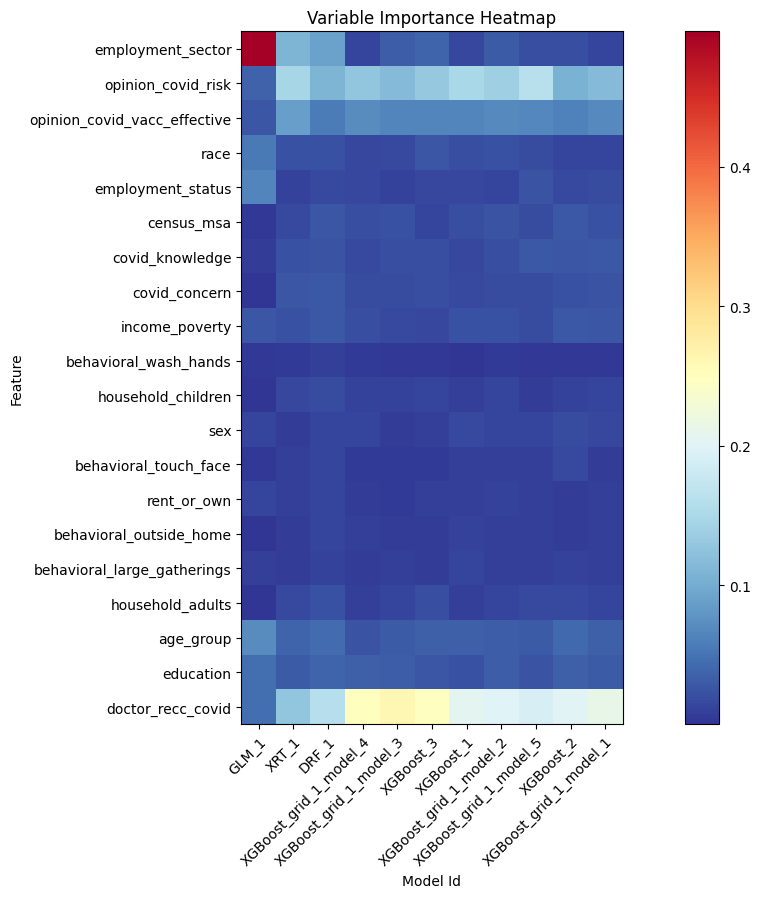

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

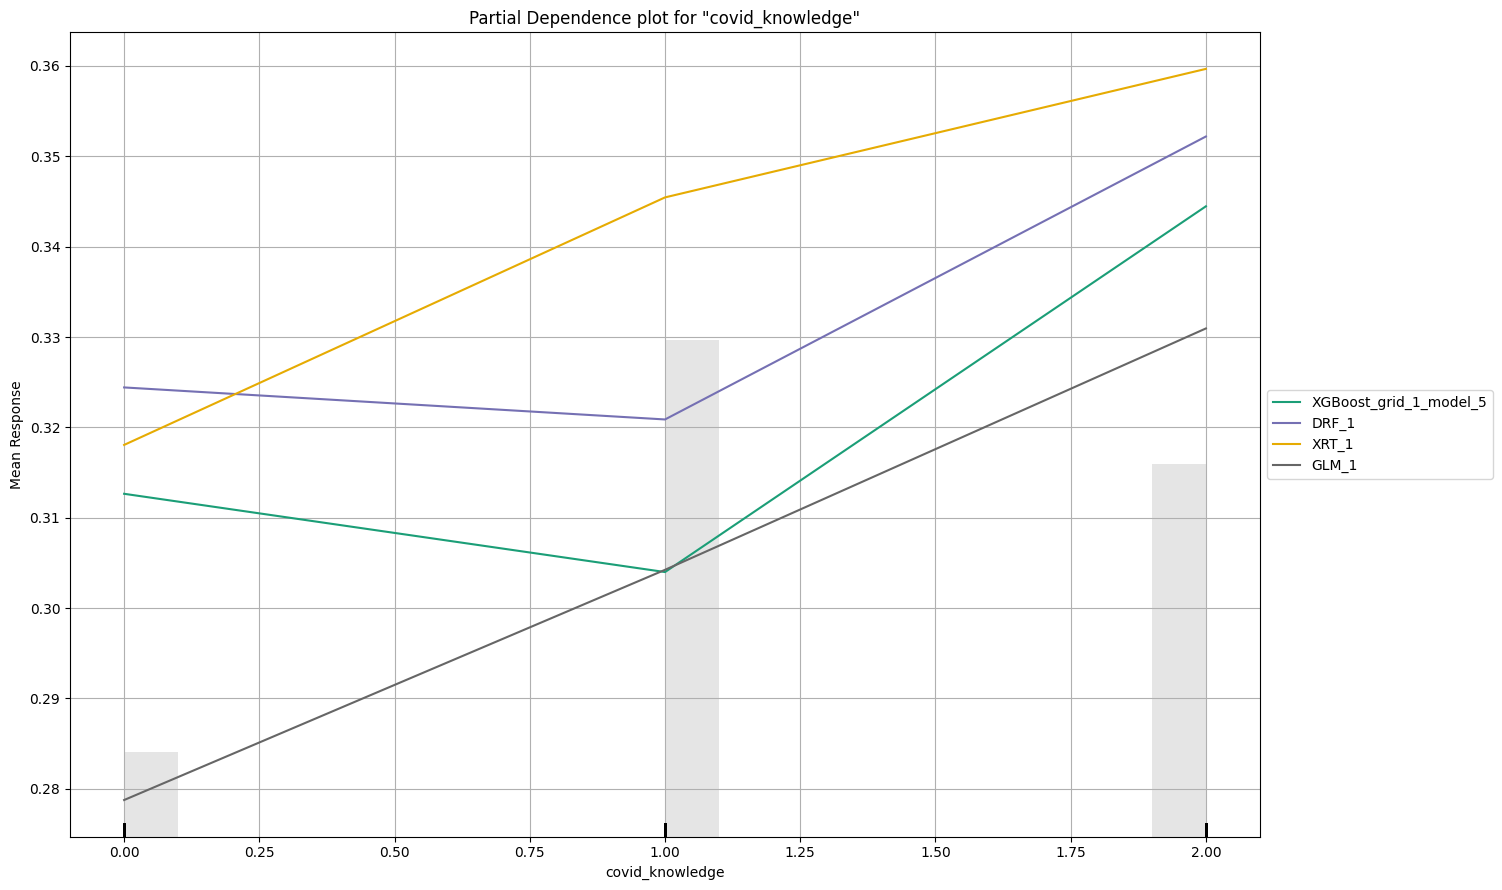

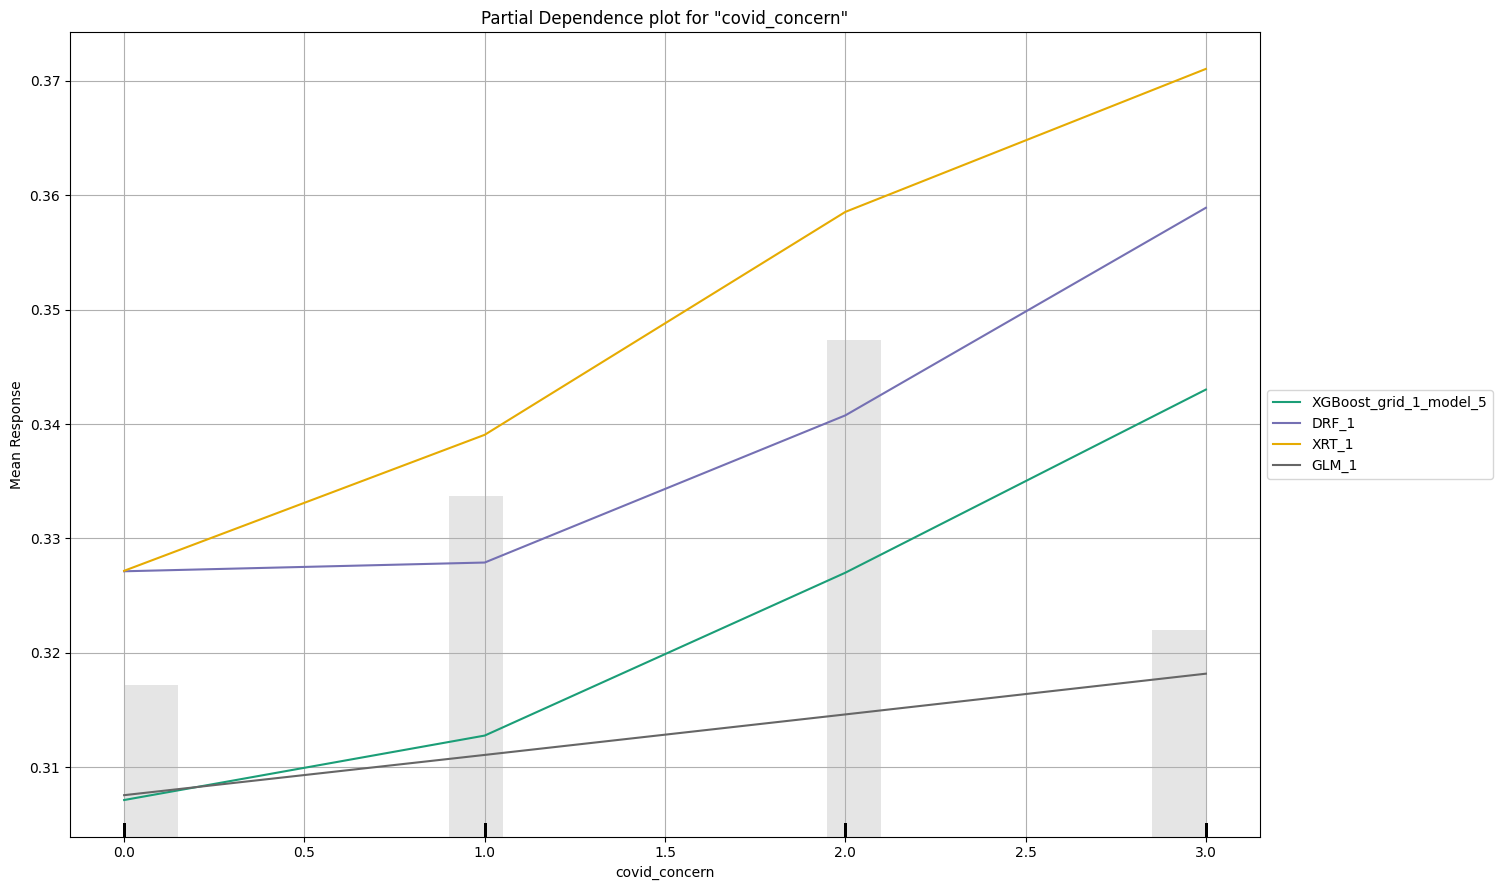

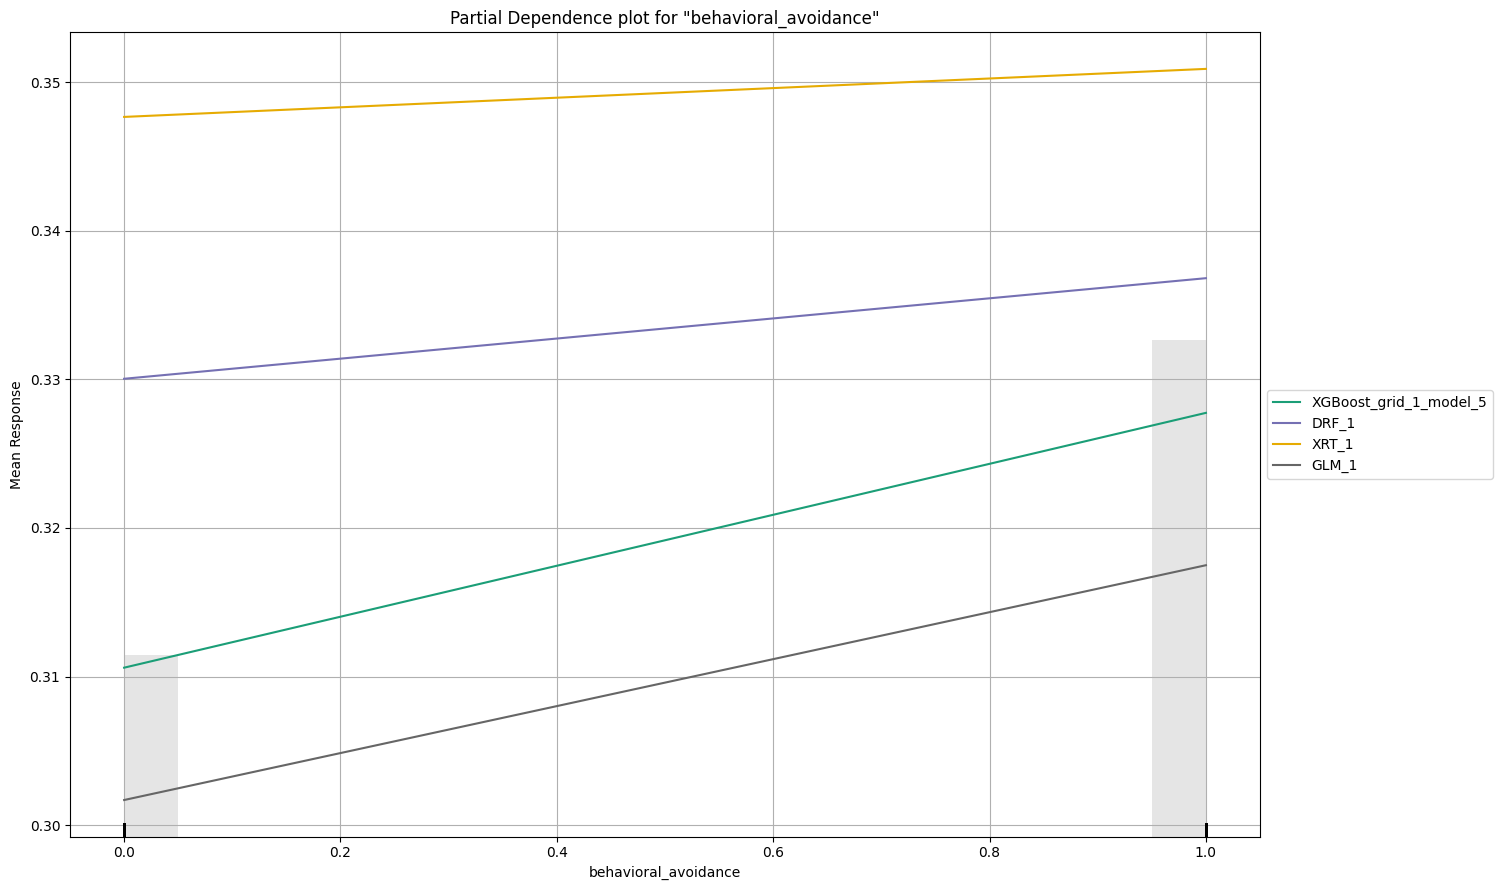

In [23]:
# Plot XAI information
aml.explain(test, include_explanations=["varimp_heatmap", "pdp"], \
            columns = ["covid_knowledge", "covid_concern", "behavioral_avoidance"]);

In [24]:
best_model = aml.leader
predictions = best_model.predict(test)

# Display predictions (first 5 rows)
print("Predictions:")
predictions.head()

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%
Predictions:


predict,p0,p1
0,0.976655,0.0233447
1,0.367548,0.632452
0,0.93974,0.0602596
0,0.828519,0.171481
0,0.927186,0.0728135
0,0.953225,0.0467748
1,0.506704,0.493296
1,0.561073,0.438927
0,0.988414,0.0115864
0,0.765232,0.234768


In [25]:
print("Model performance on test set:")
performance = best_model.model_performance(test)
print(performance)

Model performance on test set:
ModelMetricsBinomial: xgboost
** Reported on test data. **

MSE: 0.14219884685551562
RMSE: 0.37709262370870583
LogLoss: 0.4475170277912488
Mean Per-Class Error: 0.2213561413204128
AUC: 0.8506551298692953
AUCPR: 0.7617997228788818
Gini: 0.7013102597385905

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.35650406281153363
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      648  134  0.1714   (134.0/782.0)
1      108  290  0.2714   (108.0/398.0)
Total  756  424  0.2051   (242.0/1180.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.356504     0.705596  208
max f2                       0.134944     0.786567  303
max f0point5                 0.577314     0.732589  137
max accuracy                 0.577314     0.802542  137
max precision                0.987521     1 

In [26]:
print(f"AUC: {performance.auc()}")
print(f"F1 Score: {performance.F1()}")
print("Confusion Matrix:")
print(performance.confusion_matrix())

AUC: 0.8506551298692953
F1 Score: [[0.35650406281153363, 0.7055961070559611]]
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.35650406281153363
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      648  134  0.1714   (134.0/782.0)
1      108  290  0.2714   (108.0/398.0)
Total  756  424  0.2051   (242.0/1180.0)


vinay

In [ ]:
asd

In [ ]:
gd